# Comparison with other block encoding techniques

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import math


from laplacian_beqc import generate_laplacian_beqc, ShiftDown, ShiftUp
from utils import (
    get_circuit_unitary,
    plot_heatmap,
    lap1d_fd,
    generate_laplacian,
    prepare_v_vector,
)
from fable import fable
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Operator
from qiskit.qasm3 import load
from qiskit.circuit.library import *
from matplotlib.ticker import ScalarFormatter
from qiskit_ibm_runtime.fake_provider import FakeTorino

import warnings

warnings.filterwarnings(
    "ignore",
    message=".*encountered in det.*",
    category=RuntimeWarning,
)

backend = FakeTorino()


# Formatting plots
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.1,
    "lines.markersize": 4,
    "text.usetex": True,
    "font.family": "serif",
})

colors = {
    "ours": "tab:blue",
    "camps": "tab:orange",
    "sunderhauf": "tab:orange",
    "bitble": "tab:green",
    "fable": "tab:red",
}

markers = {
    "ours": "o",
    "camps": "s",
    "sunderhauf": "s",
    "bitble": "^",
    "fable": "d",
}

## Other Laplacian block-encoding quantum circuits

### 1. Camps et al. 2023

This work provides for explicit quantum circuits to block encode a 1D Laplacian matrix, with either Dirichlet or Periodic boundary conditions.

In [2]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import RYGate, StatePreparation


def camps_banded_circulant_mat(
    nq, alpha, beta, gamma, tridiag=False, save_unitary=True
):
    """https://arxiv.org/pdf/2203.10236"""

    assert 0 <= alpha
    assert alpha <= 2
    assert abs(beta) <= 1
    assert abs(gamma) <= 1

    j_reg = QuantumRegister(nq, "j")
    data_reg = QuantumRegister(1, "data")
    l_reg = QuantumRegister(2, "l")

    qc = QuantumCircuit(j_reg, l_reg, data_reg)

    # Diffusion
    qc.h(l_reg)

    # OA
    theta0 = 2 * np.arccos(alpha - 1)
    theta1 = 2 * np.arccos(beta)
    theta2 = 2 * np.arccos(gamma)

    qc.append(RYGate(theta0).control(2, ctrl_state="00"), l_reg[:] + data_reg[:])
    qc.append(RYGate(theta1).control(2, ctrl_state="01"), l_reg[:] + data_reg[:])
    qc.append(RYGate(theta2).control(2, ctrl_state="10"), l_reg[:] + data_reg[:])

    if tridiag:
        qc.append(
            RYGate(np.pi - theta1).control(nq + 2, ctrl_state="1" * nq + "01"),
            l_reg[:] + j_reg[:] + data_reg[:],
        )
        qc.append(
            RYGate(np.pi - theta2).control(nq + 2, ctrl_state="0" * nq + "10"),
            l_reg[:] + j_reg[:] + data_reg[:],
        )

    # OC
    qc.append(ShiftUp(nq).control(1), [l_reg[0]] + j_reg[:])
    qc.append(ShiftDown(nq).control(1), [l_reg[1]] + j_reg[:])

    # Diffusion
    qc.h(l_reg)

    if save_unitary:
        qc.save_unitary()

    return qc

### 2. Sunderhauf et al. 2024

This work provides for explicit quantum circuits to block encode a 2D Laplacian matrix, with Dirichlet boundary conditions along both dimensions.

In [3]:
def unique_val_lap(laplacian, Nx):
    """Extract unique diagonal values from a 2D Laplacian matrix."""
    unique_values = [
        laplacian.diagonal(0)[0],  # Main diagonal (A0)
        laplacian.diagonal(1)[0],  # Next lower diagonal (A1)
        laplacian.diagonal(Nx)[0],  # Final diagonal (A2)
    ]
    return unique_values


def make_incrementer(n: int):
    circ = QuantumCircuit(n, name=f"INC{n}")
    for i in range(n - 1, 0, -1):
        circ.mcx(list(range(i)), i)
    circ.x(0)
    return circ.to_gate()


def make_decrementer(n: int):
    inc = make_incrementer(n)
    dec = inc.inverse()
    dec.name = f"DEC{n}"
    return dec


def prep_lap(reg: QuantumRegister, vec: list[float]):
    qc = QuantumCircuit(reg)
    prep = StatePreparation(vec)
    qc.append(prep, reg)
    return qc


def unprep_lap(reg: QuantumRegister, vec: list[float]):
    prep_qc = prep_lap(reg, vec)
    unitary = Operator(prep_qc).data
    inv_unitary = np.conj(unitary.T)
    qc = QuantumCircuit(reg)
    prep_inv_gate = UnitaryGate(inv_unitary)
    qc.append(prep_inv_gate, reg)
    return qc


def oracle_org(qc, dl_reg, j_reg, s_reg, j1, j2, jx, jy):
    oracle_100 = XGate().control(3, ctrl_state="001")
    qc.append(oracle_100, [s_reg[0], s_reg[1], s_reg[2], dl_reg[0]])
    oracle_01_jy = XGate().control(j1 + 1, ctrl_state=("1" + "0" * j1))
    qc.append(oracle_01_jy, jx + [s_reg[1], dl_reg[0]])
    oracle_01_jx = XGate().control(j2 + 1, ctrl_state=("1" + "0" * j2))
    qc.append(oracle_01_jx, jy + [s_reg[2], dl_reg[0]])


def oracle_d(qc: QuantumCircuit, TM: list[float], data_regs: list, s_reg: list):
    """
    Apply a multi‐controlled RX on each data qubit in data_regs,
    with angles 2*arccos(TM[i]) controlled on the bitstring i of s_reg[1:].

    Args:
        qc        : your QuantumCircuit
        TM        : list of length 2**n_controls of amplitudes
        data_regs : list of target qubits (e.g. [data_reg[0]])
        s_reg     : full s register (we’ll use s_reg[1:] as controls)
    """
    controls = [s_reg[1], s_reg[2]]
    n_ctrl = len(controls)

    if len(TM) != 2**n_ctrl:
        raise ValueError(f"TM must have length 2**{n_ctrl} (got {len(TM)})")

    for i, amp in enumerate(TM):
        angle = 2 * np.arccos(amp)
        ctrl_state = format(i, "02b")
        gate = RXGate(angle).control(2, ctrl_state=ctrl_state)
        qc.append(gate, controls + [data_regs[0]])

    return qc


def sunderhauf_block_encoding(
    Nx, Ny, scaled_laplacian, v_normed=None, save_unitary=True
):
    "https://quantum-journal.org/papers/q-2024-01-11-1226/"

    unique_values_laplacian = unique_val_lap(scaled_laplacian, Nx)
    unique_values_laplacian.append(0)

    data_reg = QuantumRegister(1, "data")
    dlt_reg = QuantumRegister(1, "dlt")
    s_reg = QuantumRegister(3, "s")  # Corresponds to s0, s1, s2
    j1, j2 = int(math.log2(Nx)), int(math.log2(Ny))
    j_reg = QuantumRegister(j1 + j2, "j")
    jx, jy = j_reg[:j1], j_reg[j1:]
    qc = QuantumCircuit(j_reg, s_reg, dlt_reg, data_reg)

    if v_normed is not None:
        qc.append(StatePreparation(v_normed), j_reg)

    vec = [
        np.sqrt(1 / 5),
        0,
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        0,
        0,
    ]

    prep = prep_lap(s_reg, vec)
    qc.append(prep, s_reg)

    add_1_to_jy = make_incrementer(j2).control(2, ctrl_state="10")
    add_1_to_j = make_incrementer(int(j1 + j2)).control(2, ctrl_state="10")
    qc.append(add_1_to_jy, [s_reg[0], s_reg[2]] + jy)  # [::-1]
    qc.append(add_1_to_j, [s_reg[0], s_reg[1]] + list(j_reg))  # [::-1]

    oracle_org(qc, dlt_reg, j_reg, s_reg, j1, j2, jx, jy)
    qc.z(data_reg[0])
    oracle_d(qc, unique_values_laplacian, data_reg, s_reg)
    qc.cx(s_reg[1], s_reg[0])
    qc.cx(s_reg[2], s_reg[0])

    sub_1_to_jx = make_decrementer(int(j1 + j2)).control(2, ctrl_state="10")
    qc.append(sub_1_to_jx, [s_reg[0], s_reg[1]] + list(j_reg))
    sub_1_to_j = make_decrementer(j2).control(2, ctrl_state="10")
    qc.append(sub_1_to_j, [s_reg[0], s_reg[2]] + jy)

    prep_dagger = unprep_lap(s_reg, vec)
    qc.append(prep_dagger, s_reg)

    if save_unitary:
        qc.save_unitary()

    return qc

## Benchmarking

### Metrics used: circuit depth, 2-qubit gate count, and total number of gates

For uniformity, we transpile all the block encoding quantum circuits using the basis gates of the Heron processor of IBM.

#### 1D Laplacian with Dirichlet/periodic BCs

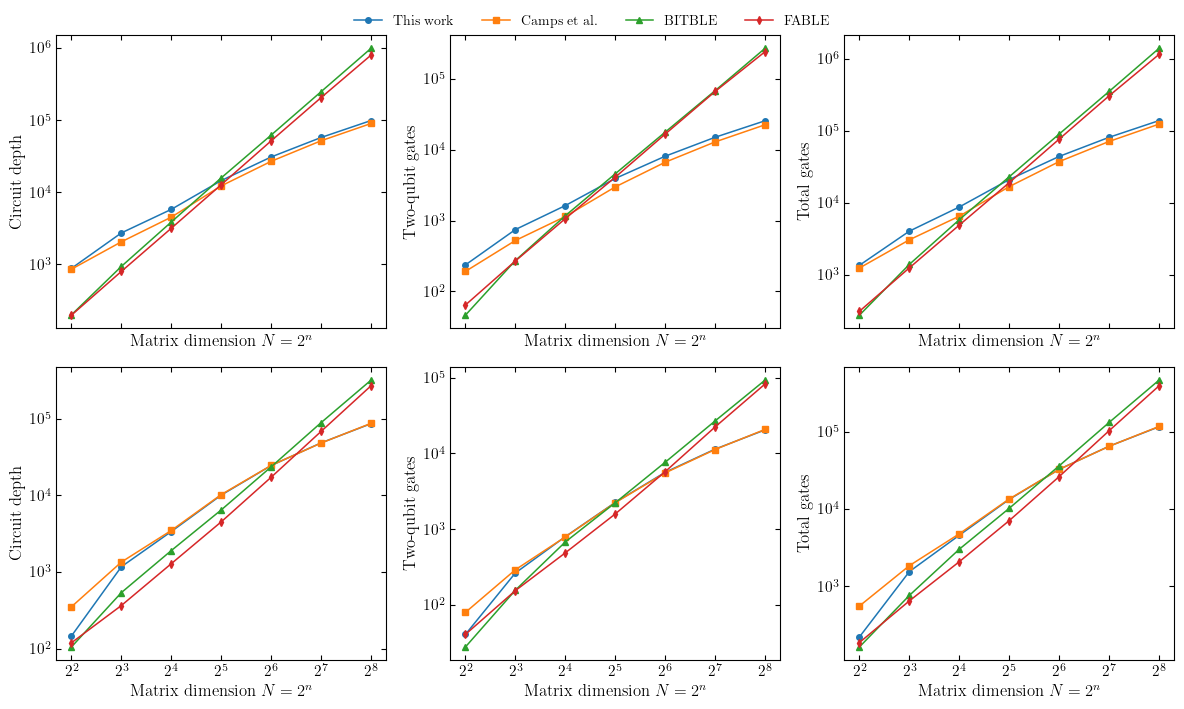

In [5]:
nqs = list(range(2, 9))
npoints = 2 ** np.array(nqs)

our_be_dbc_depth = []
our_be_pbc_depth = []
camps_be_dbc_depth = []
camps_be_pbc_depth = []
bitble_dbc_depth = []
bitble_pbc_depth = []
fable_dbc_depth = []
fable_pbc_depth = []

our_be_dbc_2qg = []
our_be_pbc_2qg = []
camps_be_dbc_2qg = []
camps_be_pbc_2qg = []
bitble_dbc_2qg = []
bitble_pbc_2qg = []
fable_dbc_2qg = []
fable_pbc_2qg = []


our_be_dbc_total = []
our_be_pbc_total = []
camps_be_dbc_total = []
camps_be_pbc_total = []
bitble_dbc_total = []
bitble_pbc_total = []
fable_dbc_total = []
fable_pbc_total = []


for nq in nqs:
    ###############################
    ######## Dirichlet BCs ########
    ###############################

    # - Our block-encoding
    qc = generate_laplacian_beqc([nq], save_unitary=False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    our_be_dbc_depth.append(transpiled.depth())
    our_be_dbc_2qg.append(twoq_count)
    our_be_dbc_total.append(sum(counts.values()))

    # - Camps et al.
    qc = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, True, False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    camps_be_dbc_depth.append(transpiled.depth())
    camps_be_dbc_2qg.append(twoq_count)
    camps_be_dbc_total.append(sum(counts.values()))

    # - BITBLE1
    qc = load(f"bitble_circuits/1d/dirichlet/bitble1_{nq}qubits.qasm")
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    bitble_dbc_depth.append(transpiled.depth())
    bitble_dbc_2qg.append(twoq_count)
    bitble_dbc_total.append(sum(counts.values()))

    # - FABLE
    matrix = generate_laplacian(shape=[2**nq], bcs=["dirichlet"])
    qc_fable, _ = fable(matrix.toarray(), 0)
    transpiled = transpile(qc_fable, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    fable_dbc_depth.append(transpiled.depth())
    fable_dbc_2qg.append(twoq_count)
    fable_dbc_total.append(sum(counts.values()))

    ###############################
    ######## Periodic BCs ########
    ###############################

    # - Our block-encoding
    qc = generate_laplacian_beqc([nq], bcs=["periodic"], save_unitary=False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    our_be_pbc_depth.append(transpiled.depth())
    our_be_pbc_2qg.append(twoq_count)
    our_be_pbc_total.append(sum(counts.values()))

    # - Camps et al.
    qc = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, False, False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    camps_be_pbc_depth.append(transpiled.depth())
    camps_be_pbc_2qg.append(twoq_count)
    camps_be_pbc_total.append(sum(counts.values()))

    # BITBLE
    qc = load(f"bitble_circuits/1d/periodic/bitble1_{nq}qubits.qasm")
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    bitble_pbc_depth.append(transpiled.depth())
    bitble_pbc_2qg.append(twoq_count)
    bitble_pbc_total.append(sum(counts.values()))

    # - FABLE
    matrix = generate_laplacian(shape=[2**nq], bcs=["periodic"])
    qc_fable, _ = fable(matrix.toarray(), 0)
    transpiled = transpile(qc_fable, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    fable_pbc_depth.append(transpiled.depth())
    fable_pbc_2qg.append(twoq_count)
    fable_pbc_total.append(sum(counts.values()))


fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)

# =====================================================
# Row 1 — Dirichlet
# =====================================================

# Depth
axes[0, 0].plot(
    npoints,
    our_be_dbc_depth,
    marker=markers["ours"],
    color=colors["ours"],
    label="This work",
)
axes[0, 0].plot(
    npoints,
    camps_be_dbc_depth,
    marker=markers["camps"],
    color=colors["camps"],
    label="Camps et al.",
)
axes[0, 0].plot(
    npoints,
    bitble_dbc_depth,
    marker=markers["bitble"],
    color=colors["bitble"],
    label="BITBLE",
)
axes[0, 0].plot(
    npoints,
    fable_dbc_depth,
    marker=markers["fable"],
    color=colors["fable"],
    label="FABLE",
)

axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel("Circuit depth")

# 2Q gates
axes[0, 1].plot(npoints, our_be_dbc_2qg, marker=markers["ours"], color=colors["ours"])
axes[0, 1].plot(
    npoints, camps_be_dbc_2qg, marker=markers["camps"], color=colors["camps"]
)
axes[0, 1].plot(
    npoints, bitble_dbc_2qg, marker=markers["bitble"], color=colors["bitble"]
)
axes[0, 1].plot(npoints, fable_dbc_2qg, marker=markers["fable"], color=colors["fable"])

axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("Two-qubit gates")

# Total gates
axes[0, 2].plot(npoints, our_be_dbc_total, marker=markers["ours"], color=colors["ours"])
axes[0, 2].plot(
    npoints, camps_be_dbc_total, marker=markers["camps"], color=colors["camps"]
)
axes[0, 2].plot(
    npoints, bitble_dbc_total, marker=markers["bitble"], color=colors["bitble"]
)
axes[0, 2].plot(
    npoints, fable_dbc_total, marker=markers["fable"], color=colors["fable"]
)

axes[0, 2].set_yscale("log")
axes[0, 2].set_ylabel("Total gates")

# =====================================================
# Row 2 — Periodic
# =====================================================

# Depth
axes[1, 0].plot(npoints, our_be_pbc_depth, marker=markers["ours"], color=colors["ours"])
axes[1, 0].plot(
    npoints, camps_be_pbc_depth, marker=markers["camps"], color=colors["camps"]
)
axes[1, 0].plot(
    npoints, bitble_pbc_depth, marker=markers["bitble"], color=colors["bitble"]
)
axes[1, 0].plot(
    npoints, fable_pbc_depth, marker=markers["fable"], color=colors["fable"]
)

axes[1, 0].set_yscale("log")
axes[1, 0].set_ylabel("Circuit depth")

# 2Q gates
axes[1, 1].plot(npoints, our_be_pbc_2qg, marker=markers["ours"], color=colors["ours"])
axes[1, 1].plot(
    npoints, camps_be_pbc_2qg, marker=markers["camps"], color=colors["camps"]
)
axes[1, 1].plot(
    npoints, bitble_pbc_2qg, marker=markers["bitble"], color=colors["bitble"]
)
axes[1, 1].plot(npoints, fable_pbc_2qg, marker=markers["fable"], color=colors["fable"])

axes[1, 1].set_yscale("log")
axes[1, 1].set_ylabel("Two-qubit gates")

# Total gates
axes[1, 2].plot(npoints, our_be_pbc_total, marker=markers["ours"], color=colors["ours"])
axes[1, 2].plot(
    npoints, camps_be_pbc_total, marker=markers["camps"], color=colors["camps"]
)
axes[1, 2].plot(
    npoints, bitble_pbc_total, marker=markers["bitble"], color=colors["bitble"]
)
axes[1, 2].plot(
    npoints, fable_pbc_total, marker=markers["fable"], color=colors["fable"]
)

axes[1, 2].set_yscale("log")
axes[1, 2].set_ylabel("Total gates")

# =====================================================
# Shared formatting
# =====================================================
for ax in axes.flat:
    ax.set_xscale("log", base=2)
    ax.set_xlabel(r"Matrix dimension $N=2^{n}$")
    ax.grid(False)
    ax.tick_params(direction="in", which="both", top=True, right=True)
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())

# Global legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

plt.tight_layout()
plt.savefig("figs/1d_laplacian_comparison_dp.png", bbox_inches="tight", dpi=1200)
plt.show()

#### 1D Laplacian with Neumann BC

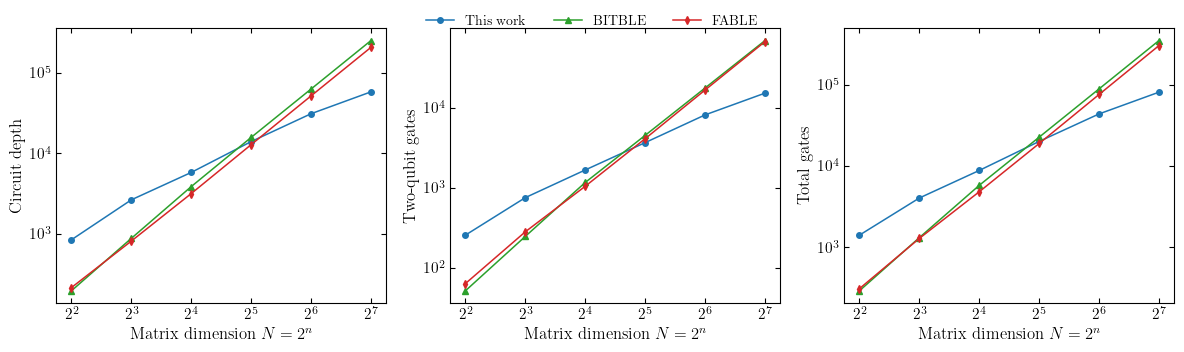

In [6]:
nqs = list(range(2, 8))
npoints = 2 ** np.array(nqs)

our_be_nbc_depth = []
bitble_nbc_depth = []
fable_nbc_depth = []

our_be_nbc_twoqg = []
bitble_nbc_twoqg = []
fable_nbc_twoqg = []

our_be_nbc_total = []
bitble_nbc_total = []
fable_nbc_total = []

for nq in nqs:
    # - Our block-encoding
    qc = generate_laplacian_beqc([nq], ["neumann"], save_unitary=False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    our_be_nbc_depth.append(transpiled.depth())
    our_be_nbc_twoqg.append(twoq_count)
    our_be_nbc_total.append(sum(counts.values()))

    # - FABLE
    matrix = generate_laplacian(shape=[2**nq], bcs=["neumann"])
    qc_fable, _ = fable(matrix.toarray(), 0)
    transpiled = transpile(qc_fable, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    fable_nbc_depth.append(transpiled.depth())
    fable_nbc_twoqg.append(twoq_count)
    fable_nbc_total.append(sum(counts.values()))

    # - BITBLE
    qc = load(f"bitble_circuits/1d/Neumann/bitble1_{nq}qubits.qasm")
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    bitble_nbc_depth.append(transpiled.depth())
    bitble_nbc_twoqg.append(twoq_count)
    bitble_nbc_total.append(sum(counts.values()))


fig, (ax,) = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, squeeze=False)

# Depth
ax[0].plot(
    npoints,
    our_be_nbc_depth,
    marker=markers["ours"],
    color=colors["ours"],
    label="This work",
)
ax[0].plot(
    npoints,
    bitble_nbc_depth,
    marker=markers["bitble"],
    color=colors["bitble"],
    label="BITBLE",
)
ax[0].plot(
    npoints,
    fable_nbc_depth,
    marker=markers["fable"],
    color=colors["fable"],
    label="FABLE",
)

ax[0].set_yscale("log")
ax[0].set_ylabel("Circuit depth")

# 2Q gates
ax[1].plot(npoints, our_be_nbc_twoqg, marker=markers["ours"], color=colors["ours"])
ax[1].plot(npoints, bitble_nbc_twoqg, marker=markers["bitble"], color=colors["bitble"])
ax[1].plot(npoints, fable_nbc_twoqg, marker=markers["fable"], color=colors["fable"])

ax[1].set_yscale("log")
ax[1].set_ylabel("Two-qubit gates")

# Total gates
ax[2].plot(npoints, our_be_nbc_total, marker=markers["ours"], color=colors["ours"])
ax[2].plot(npoints, bitble_nbc_total, marker=markers["bitble"], color=colors["bitble"])
ax[2].plot(npoints, fable_nbc_total, marker=markers["fable"], color=colors["fable"])

ax[2].set_yscale("log")
ax[2].set_ylabel("Total gates")


# =====================================================
# Shared formatting
# =====================================================

for plot in ax:
    plot.set_xscale("log", base=2)
    plot.set_xlabel(r"Matrix dimension $N=2^{n}$")
    plot.grid(False)
    plot.tick_params(direction="in", which="both", top=True, right=True)
    plot.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    plot.yaxis.set_minor_locator(mpl.ticker.NullLocator())

# Legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

plt.tight_layout()
plt.savefig("figs/1d_laplacian_comparison_n.png", bbox_inches="tight", dpi=1200)
plt.show()

2D DD

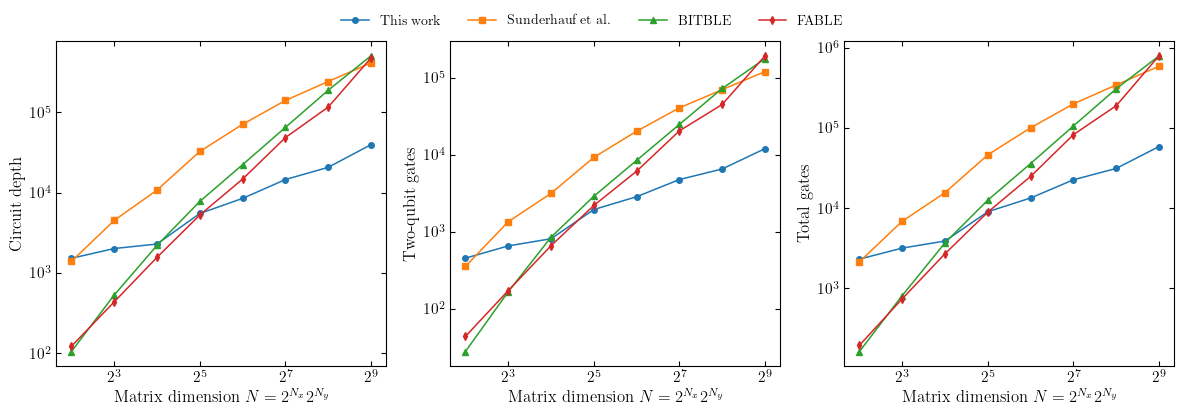

In [7]:
nqs = list(range(2, 10))
npoints = 2 ** np.array(nqs)

our_be_dd_2qg = []
sunderhauf_be_dd_2qg = []
bitble_dd_2qg = []
fable_dd_2qg = []  

our_be_dd_total = []
sunderhauf_be_dd_total = []
bitble_dd_total = []
fable_dd_total = []

our_be_dd_depth = []
sunderhauf_be_dd_depth = []
bitble_dd_depth = []
fable_dd_depth = []

for nq in nqs:
    nq1, nq2 = nq // 2, (nq + 1) // 2
    deltas = [2**-nq1, 2**-nq2]
    lap_mat = generate_laplacian((2**nq1, 2**nq2), deltas, analytic_normalize=True)

    # - Our block-encoding
    qc = generate_laplacian_beqc([nq1, nq2], deltas, save_unitary=False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    our_be_dd_depth.append(transpiled.depth())
    our_be_dd_2qg.append(twoq_count)
    our_be_dd_total.append(sum(counts.values()))

    # - Sunderhauf et al. block-encoding
    qc = sunderhauf_block_encoding(2**nq1, 2**nq2, lap_mat, save_unitary=False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    sunderhauf_be_dd_depth.append(transpiled.depth())
    sunderhauf_be_dd_2qg.append(twoq_count)
    sunderhauf_be_dd_total.append(sum(counts.values()))

    # - FABLE
    qc_fable, _ = fable(lap_mat.toarray(), 0)
    transpiled = transpile(qc_fable, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    fable_dd_depth.append(transpiled.depth())
    fable_dd_2qg.append(twoq_count)
    fable_dd_total.append(sum(counts.values()))


    # - BITBLE
    qc = load(f"bitble_circuits/2d/dd/bitble1_{nq}qubits.qasm")
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    bitble_dd_depth.append(transpiled.depth())
    bitble_dd_2qg.append(twoq_count)
    bitble_dd_total.append(sum(counts.values()))


fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

# -------------------------
# Circuit depth
# -------------------------
ax[0].plot(npoints, our_be_dd_depth, "o-", color=colors["ours"], label="This work")
ax[0].plot(npoints, sunderhauf_be_dd_depth, "s-", color=colors["sunderhauf"], label="Sunderhauf et al.")
ax[0].plot(npoints, bitble_dd_depth, "^-", color=colors["bitble"], label="BITBLE")
ax[0].plot(npoints, fable_dd_depth, "d-", color=colors["fable"], label="FABLE")

ax[0].set_xscale("log", base=2)
ax[0].set_yscale("log")
ax[0].set_ylabel("Circuit depth")

# -------------------------
# 2-qubit gates
# -------------------------
ax[1].plot(npoints, our_be_dd_2qg, "o-", color=colors["ours"])
ax[1].plot(npoints, sunderhauf_be_dd_2qg, "s-", color=colors["sunderhauf"])
ax[1].plot(npoints, bitble_dd_2qg, "^-", color=colors["bitble"])
ax[1].plot(npoints, fable_dd_2qg, "d-", color=colors["fable"])

ax[1].set_xscale("log", base=2)
ax[1].set_yscale("log")
ax[1].set_ylabel("Two-qubit gates")

# -------------------------
# Total gates
# -------------------------
ax[2].plot(npoints, our_be_dd_total, "o-", color=colors["ours"])
ax[2].plot(npoints, sunderhauf_be_dd_total, "s-", color=colors["sunderhauf"])
ax[2].plot(npoints, bitble_dd_total, "^-", color=colors["bitble"])
ax[2].plot(npoints, fable_dd_total, "d-", color=colors["fable"])

ax[2].set_xscale("log", base=2)
ax[2].set_yscale("log")
ax[2].set_ylabel("Total gates")

# -------------------------
# Shared formatting
# -------------------------
for a in ax:
    a.set_xlabel((r"Matrix dimension $N=2^{N_x}2^{N_y}$"))
    a.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    a.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    a.grid(False)
    a.tick_params(direction="in", which="both", top=True, right=True)

# Single legend above all panels
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig("2D_comparison_dd.png", bbox_inches="tight", dpi= 1200)
plt.show()

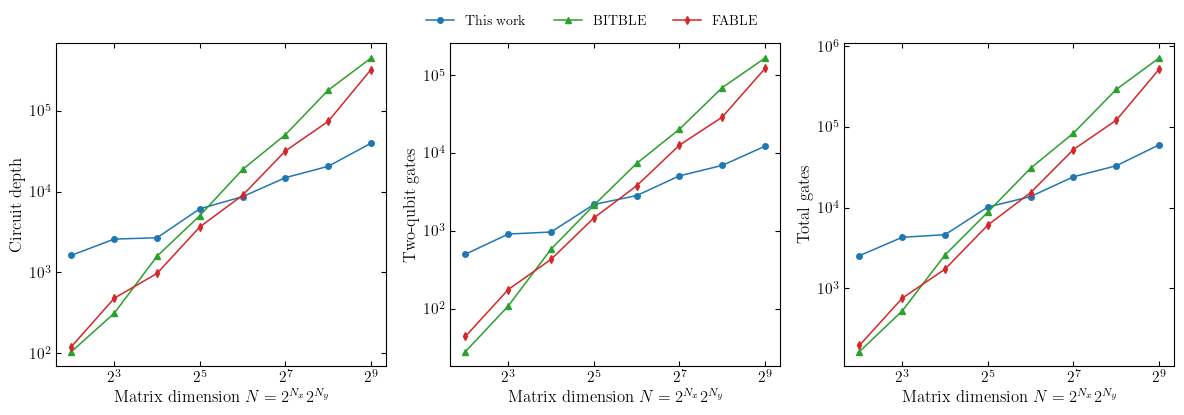

In [8]:
nqs = list(range(2, 10))
npoints = 2 ** np.array(nqs)

our_be_pn_2qg = []
bitble_pn_2qg = []
fable_pn_2qg = []  

our_be_pn_total = []
bitble_pn_total = []
fable_pn_total = []

our_be_pn_depth = []
bitble_pn_depth = []
fable_pn_depth = []

for nq in nqs:
    nq1, nq2 = nq // 2, (nq + 1) // 2
    deltas = [2**-nq1, 2**-nq2]
    lap_mat = generate_laplacian((2**nq1, 2**nq2), deltas, ["periodic", "neumann"], analytic_normalize=True)

    # - Our block-encoding
    qc = generate_laplacian_beqc([nq1, nq2], deltas, ["periodic", "neumann"], save_unitary=False)
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts.get("rzz", 0)

    our_be_pn_depth.append(transpiled.depth())
    our_be_pn_2qg.append(twoq_count)
    our_be_pn_total.append(sum(counts.values()))

    # - FABLE
    qc_fable, _ = fable(lap_mat.toarray(), 0)
    transpiled = transpile(qc_fable, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    fable_pn_depth.append(transpiled.depth())
    fable_pn_2qg.append(twoq_count)
    fable_pn_total.append(sum(counts.values()))


    # - BITBLE
    qc = load(f"bitble_circuits/2d/pn/bitble1_{nq}qubits.qasm")
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    bitble_pn_depth.append(transpiled.depth())
    bitble_pn_2qg.append(twoq_count)
    bitble_pn_total.append(sum(counts.values()))

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

# -------------------------
# Circuit depth
# -------------------------
ax[0].plot(npoints, our_be_pn_depth, "o-", color=colors["ours"], label="This work")
ax[0].plot(npoints, bitble_pn_depth, "^-", color=colors["bitble"], label="BITBLE")
ax[0].plot(npoints, fable_pn_depth, "d-", color=colors["fable"], label="FABLE")

ax[0].set_xscale("log", base=2)
ax[0].set_yscale("log")
ax[0].set_ylabel("Circuit depth")

# -------------------------
# 2-qubit gates
# -------------------------
ax[1].plot(npoints, our_be_pn_2qg, "o-", color=colors["ours"])
ax[1].plot(npoints, bitble_pn_2qg, "^-", color=colors["bitble"])
ax[1].plot(npoints, fable_pn_2qg, "d-", color=colors["fable"])

ax[1].set_xscale("log", base=2)
ax[1].set_yscale("log")
ax[1].set_ylabel("Two-qubit gates")

# -------------------------
# Total gates
# -------------------------
ax[2].plot(npoints, our_be_pn_total, "o-", color=colors["ours"])
ax[2].plot(npoints, bitble_pn_total, "^-", color=colors["bitble"])
ax[2].plot(npoints, fable_pn_total, "d-", color=colors["fable"])

ax[2].set_xscale("log", base=2)
ax[2].set_yscale("log")
ax[2].set_ylabel("Total gates")

# -------------------------
# Shared formatting
# -------------------------
for a in ax:
    a.set_xlabel((r"Matrix dimension $N=2^{N_x}2^{N_y}$"))
    a.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    a.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    a.grid(False)
    a.tick_params(direction="in", which="both", top=True, right=True)

# Single legend above all panels
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig("2D_comparison_pn.png", bbox_inches="tight", dpi= 1200)
plt.show()

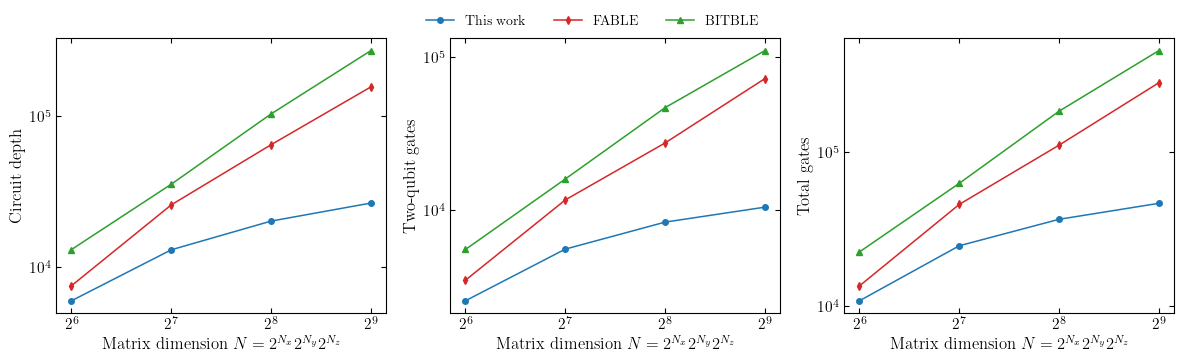

In [9]:
nqs = list(range(6, 10))
npoints = 2 ** np.array(nqs)

our_be_3d_depth = []
fable_3d_depth = []
bitble_3d_depth = []

our_be_3d_2qg = []
fable_3d_2qg = []
bitble_3d_2qg = []

our_be_3d_total = []
fable_3d_total = []
bitble_3d_total = []

for nq in nqs:
    nq1, nq2, nq3 = nq // 3, (nq + 1) // 3, (nq + 2) // 3
    deltas = [1 / 2**nq1, 1 / 2**nq2, 1 / 2**nq3]

    # - Our block encoding
    qc = generate_laplacian_beqc(
        [nq1, nq2, nq3],
        deltas=deltas,
        bcs=["periodic", "dirichlet", "neumann"],
        save_unitary=False,
    )
    transpiled = transpile(qc, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    our_be_3d_depth.append(transpiled.depth())
    our_be_3d_2qg.append(twoq_count)
    our_be_3d_total.append(sum(counts.values()))

    # - FABLE
    matrix = generate_laplacian(
        [2**nq1, 2**nq2, 2**nq3], deltas, ["periodic", "dirichlet", "neumann"]
    )
    qc_fable, _ = fable(matrix.toarray(), 0)
    transpiled = transpile(qc_fable, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    fable_3d_depth.append(transpiled.depth())
    fable_3d_2qg.append(twoq_count)
    fable_3d_total.append(sum(counts.values()))

    # - BITBLE
    qc_bitble = load(f"bitble_circuits/3d/pdn/bitble1_{nq}qubits.qasm")
    transpiled = transpile(qc_bitble, backend=backend, optimization_level=0)
    counts = transpiled.count_ops()
    twoq_count = counts.get("cz", 0) + counts.get("rzz", 0)

    bitble_3d_depth.append(transpiled.depth())
    bitble_3d_2qg.append(twoq_count)
    bitble_3d_total.append(sum(counts.values()))


fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, squeeze=False)
ax = axes[0]  # convenience view

# -------------------------
# Circuit depth
# -------------------------
ax[0].plot(npoints, our_be_3d_depth, marker=markers["ours"], color=colors["ours"], label="This work")
ax[0].plot(
    npoints,
    fable_3d_depth,
    color=colors["fable"],
    marker=markers["fable"],
    label="FABLE",
)
ax[0].plot(npoints, bitble_3d_depth, color=colors["bitble"], marker=markers["bitble"], label="BITBLE")
# ax[0].set_title("Circuit depth")
ax[0].set_ylabel("Circuit depth")

# -------------------------
# 2-qubit gates
# -------------------------
ax[1].plot(npoints, our_be_3d_2qg, marker=markers["ours"], color=colors["ours"])
ax[1].plot(
    npoints,
    fable_3d_2qg,
    color=colors["fable"],
    marker=markers["fable"],
)
ax[1].plot(npoints, bitble_3d_2qg, color=colors["bitble"], marker=markers["bitble"], label="BITBLE")
ax[1].set_ylabel("Two-qubit gates")

# -------------------------
# Total gates
# -------------------------
ax[2].plot(npoints, our_be_3d_total, marker=markers["ours"], color=colors["ours"])
ax[2].plot(
    npoints,
    fable_3d_total,
    color=colors["fable"],
    marker=markers["fable"],
)
ax[2].plot(npoints, bitble_3d_total, color=colors["bitble"], marker=markers["bitble"], label="BITBLE")
ax[2].set_ylabel("Total gates")

# -------------------------
# Shared formatting
# -------------------------
for a in ax:
    a.set_xscale("log", base=2)
    a.set_yscale("log")
    a.set_xlabel(r"Matrix dimension $N=2^{N_x}2^{N_y}2^{N_z}$")
    a.grid(False)
    a.tick_params(direction="in", which="both", top=True, right=True)
    a.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    a.yaxis.set_minor_locator(mpl.ticker.NullLocator())



handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=4,
           frameon=False,
           bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig("3d_laplacian_pdn_comparison.png", bbox_inches="tight", dpi=1200)
plt.show()

## Success probability analysis

In [10]:
def v_1d(x):
    return np.sin(2 * np.pi * x)

def v_2d(x, y):
    return np.sin(2 * np.pi * (x + y))

def v_3d(x, y, z):
    return np.sin(2 * np.pi * (x + y + z))

#### 1D Laplacian with Dirichlet/periodic/von Neumann BC

In [11]:
nqs = list(range(3, 6))
n_points = 2 ** np.array(nqs)

sprob_our_be_1d_dbc = []
sprob_camps_be_1d_dbc = []
sprob_fable_1d_dbc = []
sprob_bitble_1d_dbc = []

sprob_our_be_1d_pbc = []
sprob_camps_be_1d_pbc = []
sprob_fable_1d_pbc = []
sprob_bitble_1d_pbc = []

sprob_our_be_1d_nbc = []
sprob_fable_1d_nbc = []
sprob_bitble_1d_nbc = []

for i in range(len(nqs)):
    print(f"Running for {nqs[i]} qubits... ")
    nq = nqs[i]
    x = np.linspace(0, 1, 2**nq, endpoint=False)
    v = v_1d(x)
    v_normed = v / np.linalg.norm(v)

    ###############################
    ######## Dirichlet BCs ########
    ###############################

    # Our block encoding
    qc = generate_laplacian_beqc([nq], vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_our_be_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Camps et al.
    qc = QuantumCircuit(nq + 3)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_camps_be = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, True, True)
    qc.append(qc_camps_be, qc.qubits)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_camps_be_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_fable, _ = fable(generate_laplacian((2**nq,)).toarray(), 0)
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_fable_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # BITBLE
    qc = QuantumCircuit(2 * nq )
    qc.append(StatePreparation(v_normed), range(nq))
    qc_bitble = load(f"bitble_circuits/1d/dirichlet/bitble1_{nq}qubits.qasm")
    qc_bitble = qc_bitble.reverse_bits()
    qc.append(qc_bitble, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_bitble_1d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    
    ###############################
    ######## Periodic BCs #########
    ###############################

    # - Our block encoding
    qc = generate_laplacian_block_encoding([nq], bcs=["periodic"], vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_our_be_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # - Camps et al.
    qc = QuantumCircuit(nq + 3)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_camps_be = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, False, True)
    qc.append(qc_camps_be, qc.qubits)
    unitary = get_circuit_unitary(qc, [nq])
    sprob_camps_be_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # - FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_fable, _ = fable(generate_laplacian((2**nq,), bcs=["periodic"]).toarray(), 0)
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_fable_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # - BITBLE
    qc = QuantumCircuit(2 * nq )
    qc.append(StatePreparation(v_normed), range(nq))
    qc_bitble = load(f"bitble_circuits/1d/periodic/bitble1_{nq}qubits.qasm")
    qc_bitble = qc_bitble.reverse_bits()
    qc.append(qc_bitble, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_bitble_1d_pbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)


    ###############################
    ######### Neumann BCs #########
    ###############################

    # - Our block encoding
    qc = generate_laplacian_block_encoding([nq], vs=v_normed, bcs=["neumann"])
    unitary = get_circuit_unitary(qc, [nq])
    sprob_our_be_1d_nbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # - FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_fable, _ = fable(generate_laplacian((2**nq,), bcs=["neumann"]).toarray(), 0)
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_fable_1d_nbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # - BITBLE
    qc = QuantumCircuit(2 * nq )
    qc.append(StatePreparation(v_normed), range(nq))
    qc_bitble = load(f"bitble_circuits/1d/Neumann/bitble1_{nq}qubits.qasm")
    qc_bitble = qc_bitble.reverse_bits()
    qc.append(qc_bitble, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq])
    sprob_bitble_1d_nbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

# =====================================================
# Dirichlet
# =====================================================
axes[0].plot(n_points, sprob_our_be_1d_dbc,
             marker=markers["ours"], color=colors["ours"], label="This work")
axes[0].plot(n_points, sprob_camps_be_1d_dbc,
             marker=markers["camps"], color=colors["camps"], label="Camps et al.")
axes[0].plot(n_points, sprob_fable_1d_dbc,
             marker=markers["fable"], color=colors["fable"], label="FABLE")
axes[0].plot(n_points, sprob_bitble_1d_dbc,
             marker=markers["bitble"], color=colors["bitble"], label="BITBLE")

axes[0].set_ylabel("Success probability [\\%]")
axes[0].set_title("Dirichlet BCs")

# =====================================================
# Periodic
# =====================================================
axes[1].plot(n_points, sprob_our_be_1d_pbc,
             marker=markers["ours"], color=colors["ours"])
axes[1].plot(n_points, sprob_camps_be_1d_pbc,
             marker=markers["camps"], color=colors["camps"])
axes[1].plot(n_points, sprob_fable_1d_pbc,
             marker=markers["fable"], color=colors["fable"])
axes[1].plot(n_points, sprob_bitble_1d_pbc,
             marker=markers["bitble"], color=colors["bitble"])
axes[1].set_title("Periodic BCs")

# =====================================================
# Neumann
# =====================================================
axes[2].plot(n_points, sprob_our_be_1d_nbc,
             marker=markers["ours"], color=colors["ours"])
axes[2].plot(n_points, sprob_fable_1d_nbc,
             marker=markers["fable"], color=colors["fable"])
axes[2].plot(n_points, sprob_bitble_1d_nbc,
             marker=markers["bitble"], color=colors["bitble"])
axes[2].set_title("Neumann BCs")

# =====================================================
# Shared formatting
# =====================================================
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xlabel(r"Matrix dimension $N=2^{n}$")
    ax.grid(False)
    ax.tick_params(direction="in", which="both", top=True, right=True)
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())

# Single global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=4,
           frameon=False,
           bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig("figs/1d_success_probability.png", bbox_inches="tight", dpi=1200)
plt.show()

Running for 3 qubits... 


NameError: name 'generate_laplacian_block_encoding' is not defined

#### 2D Laplacian wth Dirichlet boundary conditions

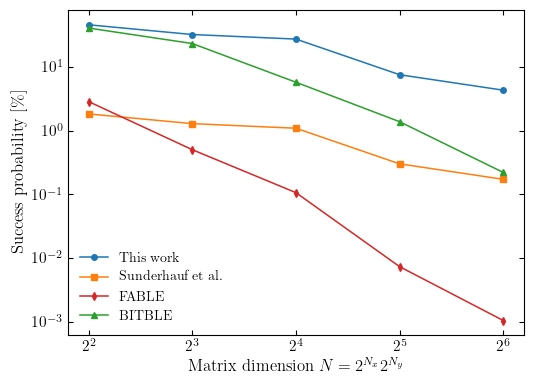

In [ ]:
nqs = list(range(2, 7))
npoints = 2 ** np.array(nqs)

sprob_our_be_2d_dbc = []
sprob_sunderhauf_be_2d_dbc = []
sprob_fable_2d_dbc = []
sprob_bitble_2d_dbc = []

for nq in nqs:
    nq1, nq2 = nq // 2, (nq + 1) // 2
    deltas = [2**-nq1, 2**-nq2]
    x = np.linspace(0, 1, 2**nq1, endpoint=False)
    y = np.linspace(0, 1, 2**nq2, endpoint=False)
    v_normed = prepare_v_vector([nq1, nq2], v_2d, deltas)
    lap_mat = generate_laplacian([2**nq1, 2**nq2], deltas, analytic_normalize=True)

    # Our block encoding
    qc = generate_laplacian_beqc([nq1, nq2], deltas=deltas, vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq1, nq2])
    sprob_our_be_2d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # Sunderhauf et al.
    qc_sunderhauf_be = sunderhauf_block_encoding(2**nq1, 2**nq2, lap_mat, v_normed)
    unitary = get_circuit_unitary(qc_sunderhauf_be, [nq1, nq2])
    sprob_sunderhauf_be_2d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc_fable, _ = fable(lap_mat.toarray(), 0)
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq1, nq2])
    sprob_fable_2d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # BITBLE
    qc = QuantumCircuit(2 * nq)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_bitble = load(f"bitble_circuits/2d/dd/bitble1_{nq}qubits.qasm").reverse_bits()
    qc.append(qc_bitble, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq1, nq2])
    sprob_bitble_2d_dbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)


fig, ax = plt.subplots(figsize=(5.5, 4))

# -------------------------------------------------
# Plot all four methods
# -------------------------------------------------
ax.plot(npoints, sprob_our_be_2d_dbc,
        marker=markers["ours"], color=colors["ours"], label="This work")

ax.plot(npoints, sprob_sunderhauf_be_2d_dbc,
        marker=markers["sunderhauf"], color=colors["sunderhauf"],
        label="Sunderhauf et al.")

ax.plot(npoints, sprob_fable_2d_dbc,
        marker=markers["fable"], color=colors["fable"],
        label="FABLE")

ax.plot(npoints, sprob_bitble_2d_dbc,
        marker=markers["bitble"], color=colors["bitble"],
        label="BITBLE")

# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax.set_xscale("log", base=2)
ax.set_yscale("log")

ax.set_xlabel(r"Matrix dimension $N=2^{N_x} 2^{N_y}$")
ax.set_ylabel(r"Success probability [\%]")

ax.grid(False)
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())

# -------------------------------------------------
# Legend
# -------------------------------------------------
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figs/2d_dd_success_probability.png", bbox_inches="tight", dpi=1200)
plt.show()

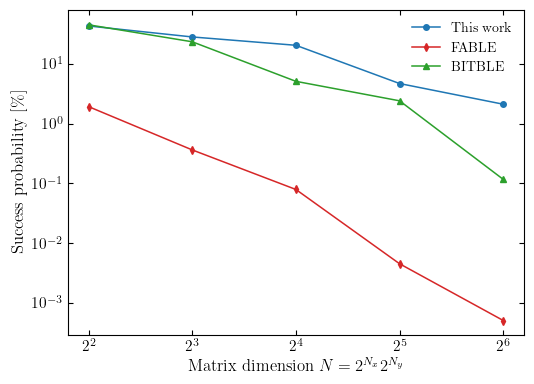

In [ ]:
nqs = list(range(2, 7))
npoints = 2 ** np.array(nqs)

sprob_our_be_2d_pnbc = []
sprob_fable_2d_pnbc = []
sprob_bitble_2d_pnbc = []

for nq in nqs:
    nq1, nq2 = nq // 2, (nq + 1) // 2
    deltas = [2**-nq1, 2**-nq2]
    x = np.linspace(0, 1, 2**nq1, endpoint=False)
    y = np.linspace(0, 1, 2**nq2, endpoint=False)
    v_normed = prepare_v_vector([nq1, nq2], v_2d, deltas)
    lap_mat = generate_laplacian([2**nq1, 2**nq2], deltas, ["periodic", "neumann"], analytic_normalize=True)

    # Our block encoding
    qc = generate_laplacian_beqc([nq1, nq2], deltas=deltas,bcs=["periodic", "neumann"], vs=v_normed)
    unitary = get_circuit_unitary(qc, [nq1, nq2])
    sprob_our_be_2d_pnbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc_fable, _ = fable(lap_mat.toarray(), 0)
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), range(nq))
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq1, nq2])
    sprob_fable_2d_pnbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # BITBLE
    qc= QuantumCircuit(2 * nq)
    qc.append(StatePreparation(v_normed), range(nq))
    qc_bitble = load(f"bitble_circuits/2d/pn/bitble1_{nq}qubits.qasm").reverse_bits()
    qc.append(qc_bitble, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq1, nq2])
    sprob_bitble_2d_pnbc.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)


fig, ax = plt.subplots(figsize=(5.5, 4))

# -------------------------------------------------
# Plot all three methods
# -------------------------------------------------
ax.plot(npoints, sprob_our_be_2d_pnbc,
        marker=markers["ours"], color=colors["ours"], label="This work")


ax.plot(npoints, sprob_fable_2d_pnbc,
        marker=markers["fable"], color=colors["fable"],
        label="FABLE")

ax.plot(npoints, sprob_bitble_2d_pnbc,
        marker=markers["bitble"], color=colors["bitble"],
        label="BITBLE")

# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax.set_xscale("log", base=2)
ax.set_yscale("log")

ax.set_xlabel(r"Matrix dimension $N=2^{N_x} 2^{N_y}$")
ax.set_ylabel(r"Success probability [\%]")

ax.grid(False)
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())

# -------------------------------------------------
# Legend
# -------------------------------------------------
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figs/2d_pn_success_probability.png", bbox_inches="tight", dpi=600)
plt.show()

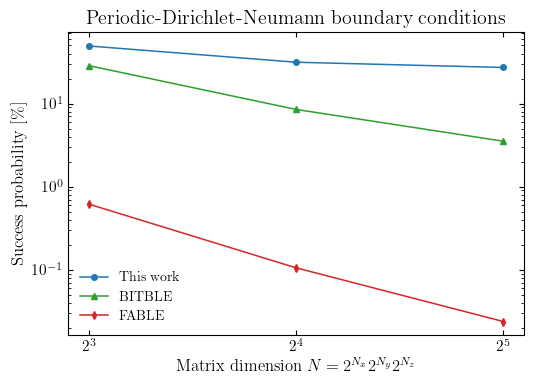

In [ ]:
nqs = list(range(3, 6))
n_points = 2 ** np.array(nqs)

sprob_our_be_3d_pdn = []
sprob_fable_3d_pdn = []
sprob_bitble_3d_pdn = []

for nq in nqs:
    nq1, nq2, nq3 = nq // 3, (nq + 1) // 3, (nq + 2) // 3
    deltas = [2**-nq1, 2**-nq2, 2**-nq3]
    v_normed = prepare_v_vector([nq1, nq2, nq3], v_3d, deltas)
    lap_mat = generate_laplacian(
        [2**nq1, 2**nq2, 2**nq3],
        deltas,
        ["periodic", "dirichlet", "neumann"],
        analytic_normalize=True,
    )

    # Our block encoding
    qc = generate_laplacian_beqc(
        [nq1, nq2, nq3], deltas, ["periodic", "dirichlet", "neumann"], v_normed
    )
    unitary = get_circuit_unitary(qc, [nq1, nq2, nq3])
    sprob_our_be_3d_pdn.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # FABLE
    qc = QuantumCircuit(2 * nq + 1)
    qc.append(StatePreparation(v_normed), qc.qubits[:nq])
    qc_fable, _ = fable(lap_mat.todense())
    qc.append(qc_fable, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq1, nq2, nq3])
    sprob_fable_3d_pdn.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)

    # BITBLE
    qc = QuantumCircuit(2 * nq)
    qc.append(StatePreparation(v_normed), qc.qubits[:nq])
    qc_bitble = load(f"bitble_circuits/3d/pdn/bitble1_{nq}qubits.qasm").reverse_bits()
    qc.append(qc_bitble, qc.qubits)
    qc.save_unitary()
    unitary = get_circuit_unitary(qc, [nq1, nq2, nq3])
    sprob_bitble_3d_pdn.append(100 * np.linalg.norm(unitary[:, 0]) ** 2)


plt.figure(figsize=(5.5, 4))
plt.plot(
    n_points,
    sprob_our_be_3d_pdn,
    color=colors["ours"],
    marker=markers["ours"],
    label="This work",
)
plt.plot(
    n_points,
    sprob_bitble_3d_pdn,
    color=colors["bitble"],
    marker=markers["bitble"],
    label="BITBLE",
)
plt.plot(
    n_points,
    sprob_fable_3d_pdn,
    color=colors["fable"],
    marker=markers["fable"],
    label="FABLE",
)

plt.xscale("log")
plt.xlabel(r"Matrix dimension $N=2^{N_x} 2^{N_y} 2^{N_z}$")

plt.yscale("log")
y_ticks = [10 ** (-i) for i in range(-1, 4)]
y_labels = ["10", "1"] + [f"$10^{{{-i}}}$" for i in range(1, 4)]
plt.yticks(y_ticks, y_labels)
plt.ylabel("Success probability [\%]")

# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax = plt.gca()
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.grid(False)
ax.tick_params(direction="in", which="both", top=True, right=True)
ax.set_xscale("log", base=2)
ax.set_yscale("log")

plt.title("Periodic-Dirichlet-Neumann boundary conditions")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("figs/3d_dpn_success_probability.png", dpi=600)
plt.show()